# 6. SDT ROC Curve Analysis (v4)

**Changes from v3:**
1. All v3 features retained (medians, slope-1 tangent, darker colors, participant-level aggregation)
2. **Criterion positioning table**: base-rate vs threshold criteria relative to slope=1 tangent, by party × theme
3. **Criterion extremity analysis**: which party holds min/max criterion per theme
4. **Below-diagonal validation**: checks whether excluded participants are disproportionately below-diagonal
5. **Logical self-consistency**: base-rate consistency deviations (FP+TN, FN+TP → 1000) by party × theme


## Setup & Data Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/My Drive/Projects/SDT/Data/cleaned_data.csv'
SAVE_DIR = '/content/drive/My Drive/Projects/SDT/Data/descriptive/'

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats as sp_stats
from scipy.stats import norm, ttest_ind, mannwhitneyu
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")

Loaded: 670 rows × 541 columns


## Data Transformation

In [ ]:
"""
Data Transformation for ROC Analysis
=====================================
"""

THEMES = ['disease', 'armed', 'conv', 'welfare', 'immi',
          'vote', 'air', 'firearm', 'auto']

THEME_NAMES = {
    'disease': 'Disease Testing',    'armed': 'Armed Conflict',
    'conv': 'Criminal Justice',      'welfare': 'Welfare Eligibility',
    'immi': 'Immigration',           'vote': 'Voting / Voter ID',
    'air': 'Airport Security',       'firearm': 'Firearms',
    'auto': 'Autonomous Driving',
}

THEME_SIGNALS = {
    'disease': 'Infected person',     'armed': 'Enemy target',
    'conv': 'Guilty defendant',       'welfare': 'Ineligible applicant',
    'immi': 'Inadmissible applicant', 'vote': 'Ineligible voter',
    'air': 'Dangerous passenger',     'firearm': 'Ineligible buyer',
    'auto': 'Hazardous situation',
}

THEME_SHORT = {
    'disease': 'Disease', 'armed': 'Armed',  'conv': 'Crime',
    'welfare': 'Welfare', 'immi': 'Immig.',  'vote': 'Voting',
    'air': 'Airport',     'firearm': 'Firearms', 'auto': 'Auto',
}

# Darker colors for better scatter visibility
PARTY_COLORS = {
    'Democrat': '#1a5276',
    'Independent': '#5d5d5d',
    'Republican': '#922b21',
}

CLIP_LO, CLIP_HI = 0.001, 0.999

# --- Derive variables ---
df['party_binary'] = np.where(
    df['party_id_7'] <= 3, 'Democrat',
    np.where(df['party_id_7'] >= 5, 'Republican', 'Independent')
)

for theme in THEMES:
    fnr_col = f'{theme}_fnr'
    if fnr_col not in df.columns and f'{theme}_tpr' in df.columns:
        df[fnr_col] = 1.0 - df[f'{theme}_tpr']

def get_mask(df):
    return df['passes_attention'] == 1

# --- Build long format ---
def collect_sdt_long(df, attentive=True):
    if attentive:
        df = df[get_mask(df)].copy()

    df = df.copy()
    rows = []
    for theme in THEMES:
        fpr_col, tpr_col = f'{theme}_fpr', f'{theme}_tpr'
        dp_col, c_col = f'{theme}_d_prime', f'{theme}_c'
        sdt_col = f'{theme}_can_sdt'
        lr_col = f'{theme}_err_log_ratio'

        for idx, row in df.iterrows():
            fpr = row.get(fpr_col, np.nan)
            tpr = row.get(tpr_col, np.nan)
            if pd.isna(fpr) and pd.isna(tpr):
                continue

            rows.append({
                'participant': row.get('ResponseId', idx),
                'theme': theme,
                'theme_name': THEME_NAMES.get(theme, theme),
                'fpr': fpr,
                'tpr': tpr,
                'd_prime': row.get(dp_col, np.nan),
                'c': row.get(c_col, np.nan),
                'can_sdt': row.get(sdt_col, False),
                'log_ratio': row.get(lr_col, np.nan),
                'party_binary': row.get('party_binary', np.nan),
                'party_id_7': row.get('party_id_7', np.nan),
            })

    return pd.DataFrame(rows)

sdt_long = collect_sdt_long(df, attentive=True)
print(f"Long SDT data: {len(sdt_long)} obs from {sdt_long['participant'].nunique()} participants")

Long SDT data: 4543 obs from 649 participants


## Helper Functions

In [ ]:
def roc_curve_from_dprime(d_prime, n_points=200):
    """Generate (FPR, TPR) points along an iso-d' ROC curve."""
    c_range = np.linspace(-4, 4, n_points)
    return norm.cdf(-d_prime/2 - c_range), norm.cdf(d_prime/2 - c_range)

def criterion_to_roc_point(d_prime, c_val):
    """Convert (d', c) to an (FPR, TPR) point on the ROC."""
    return norm.cdf(-d_prime/2 - c_val), norm.cdf(d_prime/2 - c_val)

def slope1_tangent_point(d_prime):
    """
    Find the point on the ROC curve where slope = 1.
    This is the criterion c=0 point (neutral criterion),
    which occurs at FPR = Phi(-d'/2), TPR = Phi(d'/2).
    It marks the 1:1 error trade-off.
    """
    return norm.cdf(-d_prime / 2), norm.cdf(d_prime / 2)

def add_slope1_tangent(ax, d_prime, color='gray', alpha=0.4):
    """
    Add a light tangent line with slope=1 through the c=0 point on the ROC.
    """
    fpr_t, tpr_t = slope1_tangent_point(d_prime)
    # Line through (fpr_t, tpr_t) with slope 1
    x_range = np.linspace(0, 1, 100)
    y_line = tpr_t + (x_range - fpr_t)
    valid = (y_line >= 0) & (y_line <= 1)
    ax.plot(x_range[valid], y_line[valid], color=color, linewidth=0.8,
            alpha=alpha, linestyle=':', zorder=1)


def add_roc_background(ax):
    """Add chance diagonal, iso-d' contours, and axis labels."""
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1)
    for dp_val in [0.5, 1.0, 1.5, 2.0]:
        fc, tc = roc_curve_from_dprime(dp_val)
        ax.plot(fc, tc, color='gray', alpha=0.12, linewidth=0.8)
        mid = len(fc) // 2
        ax.annotate(f"d'={dp_val}", xy=(fc[mid], tc[mid]),
                    fontsize=7, color='gray', alpha=0.35)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel('FPR', fontsize=10)
    ax.set_ylabel('TPR', fontsize=10)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.12)

## Per-Theme ROC Scatter Plots
Individual participant operating points colored by party.

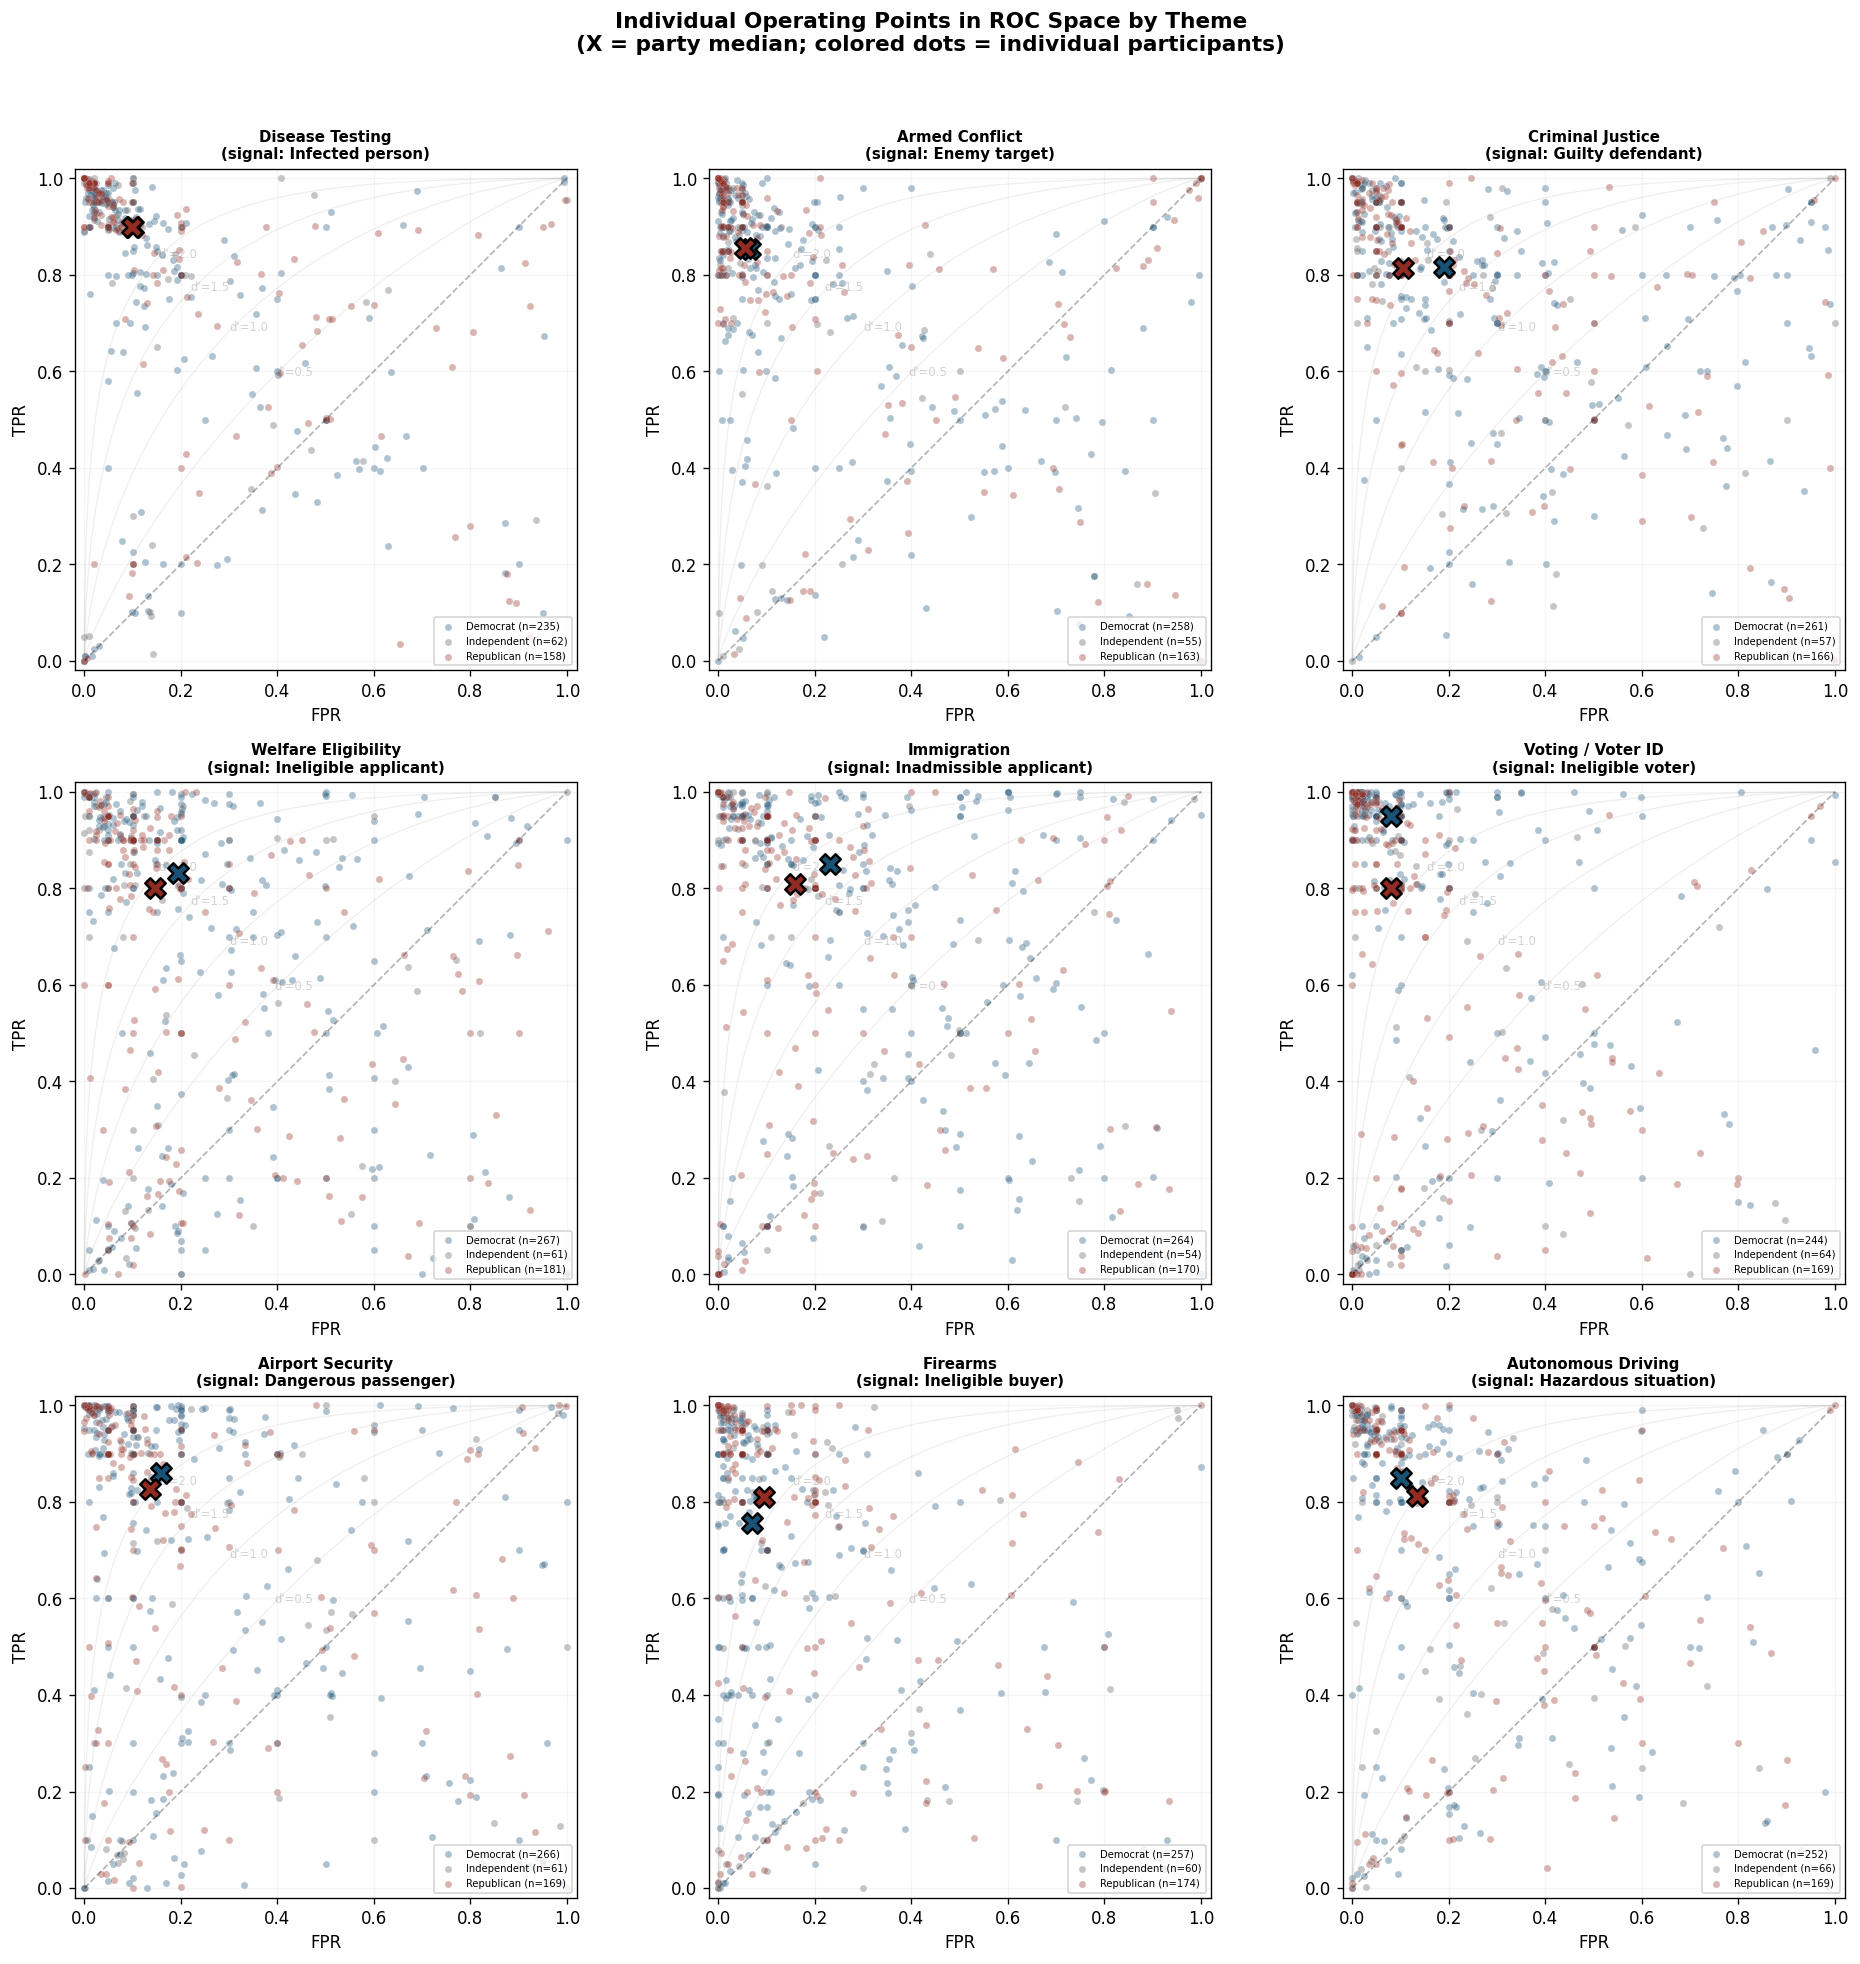

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 16))
axes = axes.flatten()

for i, theme in enumerate(THEMES):
    ax = axes[i]
    td = sdt_long[sdt_long['theme'] == theme].dropna(subset=['fpr', 'tpr'])
    add_roc_background(ax)

    # Individual points
    for party in ['Democrat', 'Independent', 'Republican']:
        pdata = td[td['party_binary'] == party]
        if len(pdata) > 0:
            ax.scatter(pdata['fpr'], pdata['tpr'],
                       c=PARTY_COLORS[party], alpha=0.35, s=18,
                       edgecolors='white', linewidth=0.2,
                       label=f"{party} (n={len(pdata)})")

    # Party MEDIAN markers (changed from mean)
    for party in ['Democrat', 'Republican']:
        pdata = td[td['party_binary'] == party]
        if len(pdata) >= 3:
            med_fpr = pdata['fpr'].median()
            med_tpr = pdata['tpr'].median()
            ax.scatter(med_fpr, med_tpr, c=PARTY_COLORS[party],
                       s=150, marker='X', edgecolors='black', linewidth=1.5, zorder=5)

    ax.set_title(f"{THEME_NAMES[theme]}\n(signal: {THEME_SIGNALS[theme]})",
                 fontsize=9, fontweight='bold')
    ax.legend(fontsize=6, loc='lower right')

fig.suptitle('Individual Operating Points in ROC Space by Theme\n'
             '(X = party median; colored dots = individual participants)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Per-Theme ROC Curves by Party
Each party's MEDIAN d' determines their ROC curve; MEDIAN c determines
their operating point on that curve. Slope-1 tangent lines added.

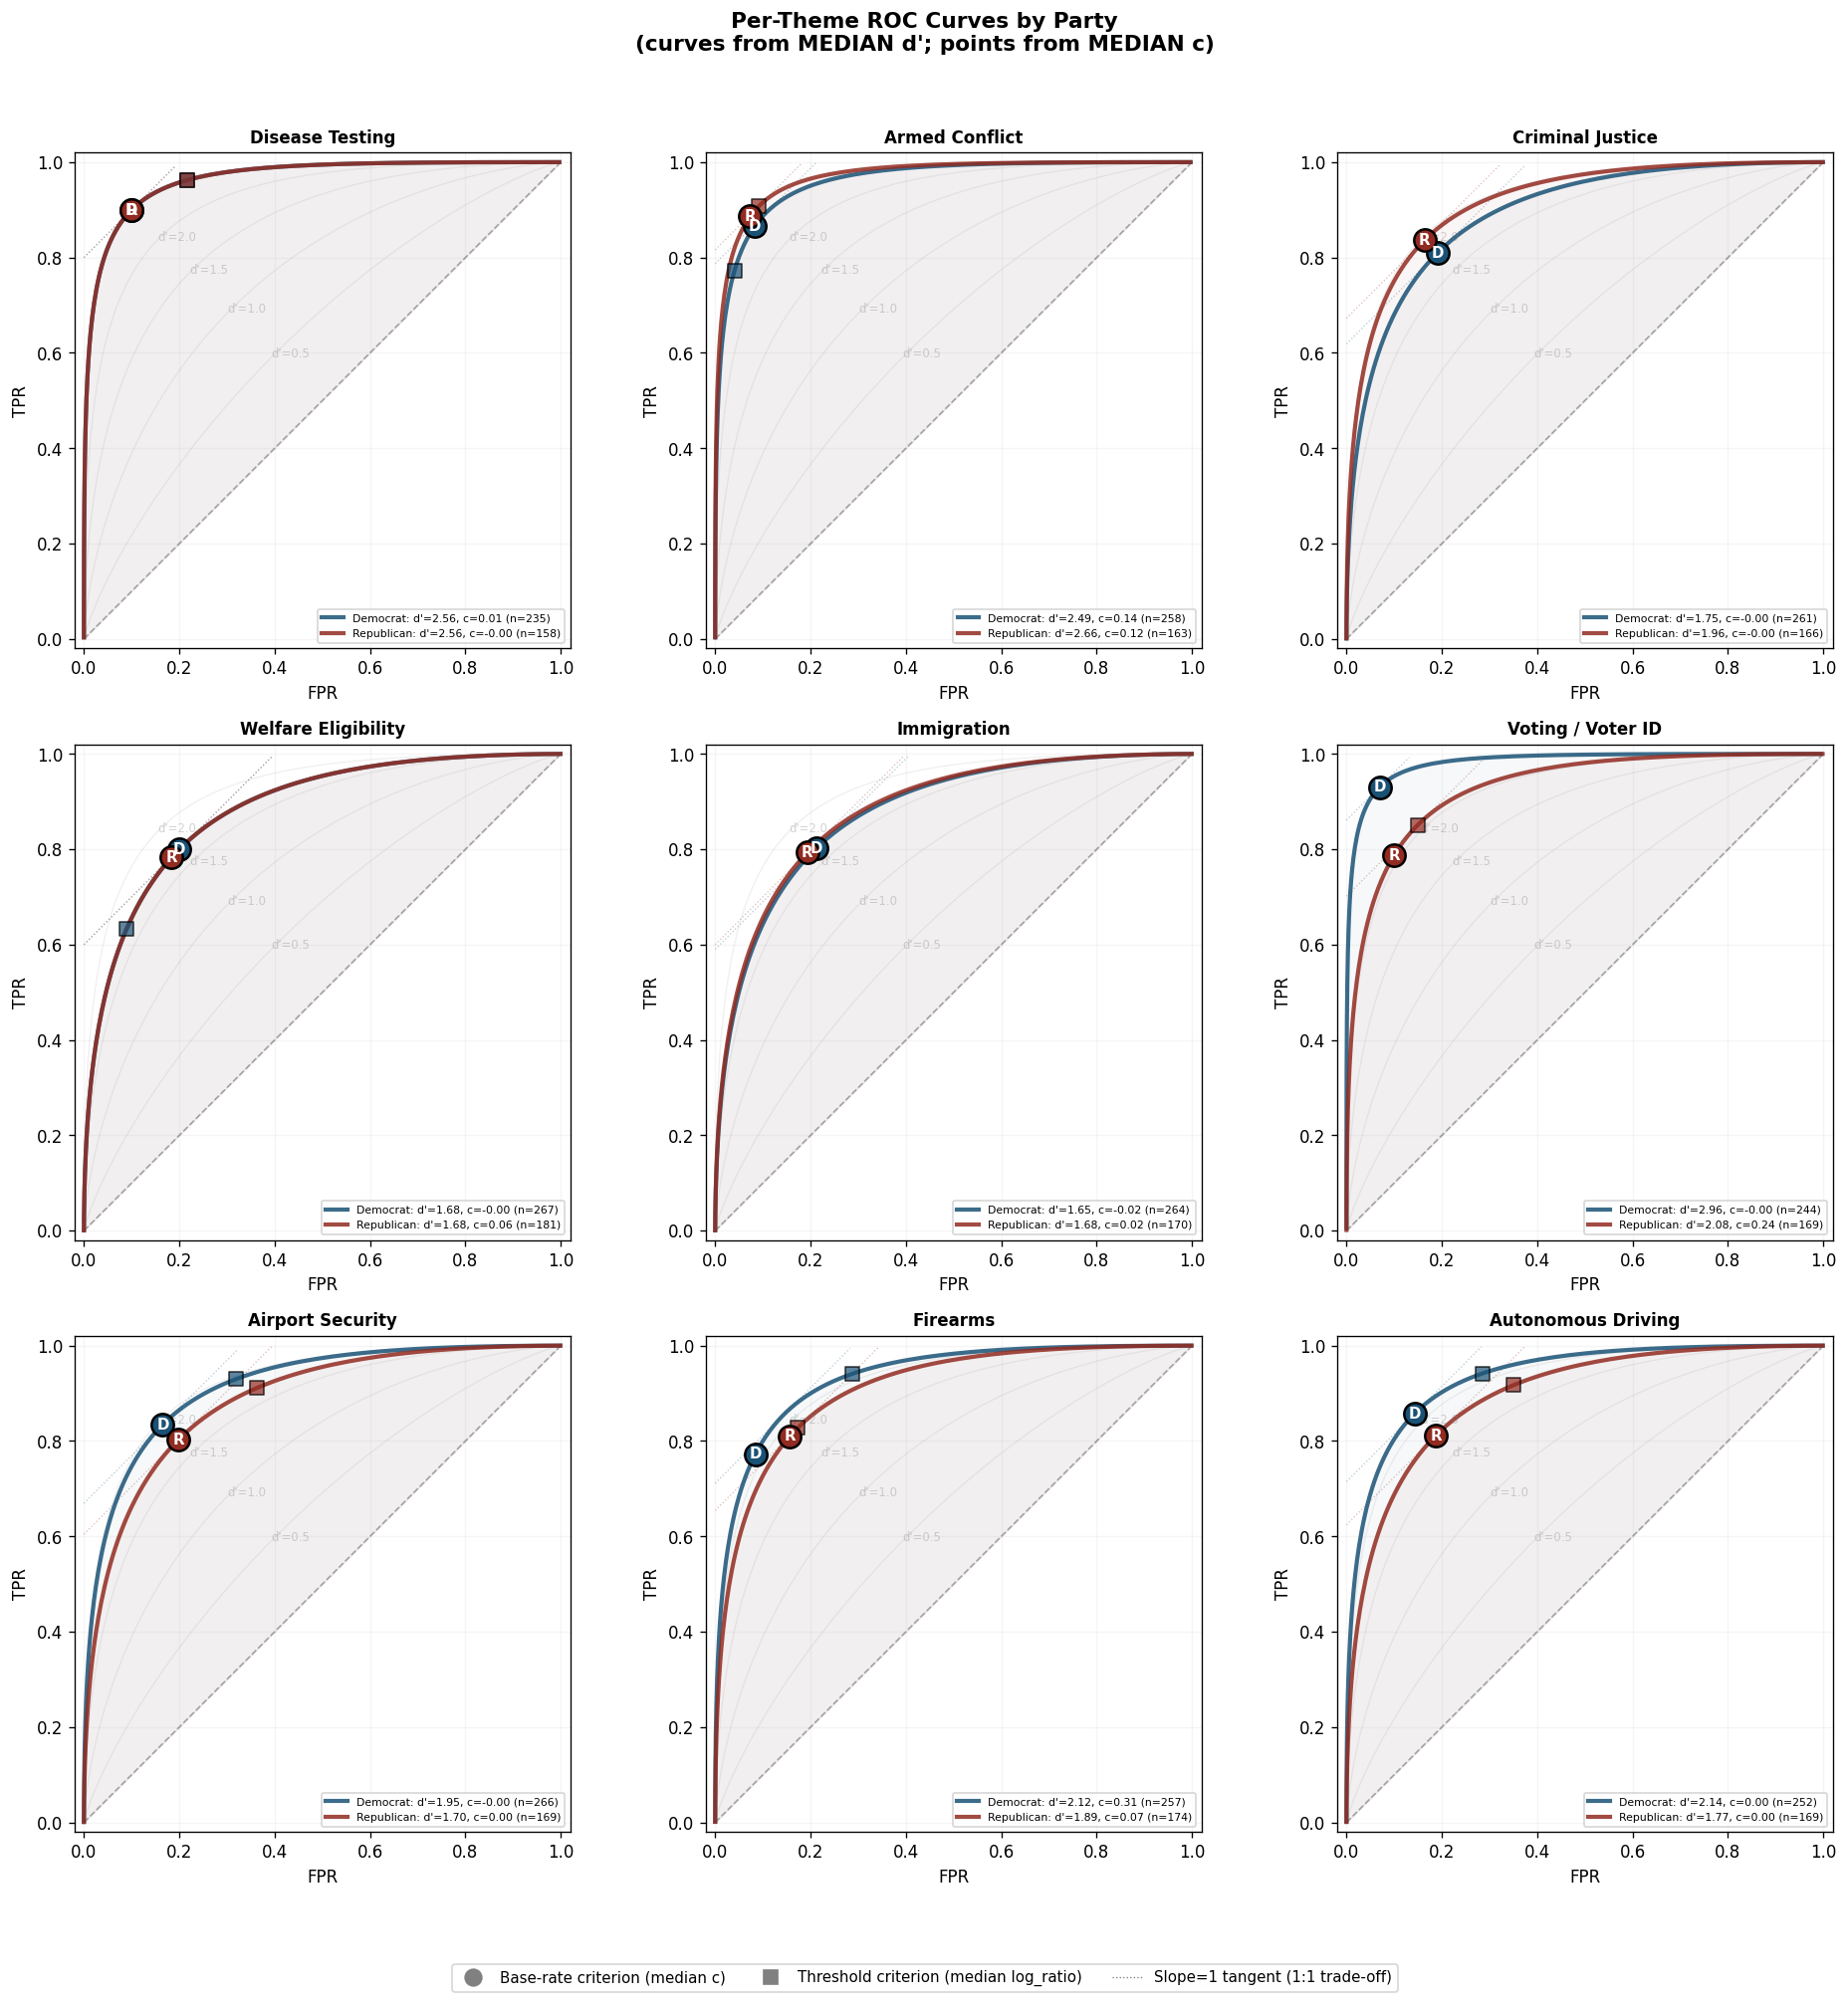

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 16))
axes = axes.flatten()

roc_stats = []

for i, theme in enumerate(THEMES):
    ax = axes[i]
    td = sdt_long[sdt_long['theme'] == theme].dropna(subset=['d_prime', 'c'])
    add_roc_background(ax)

    for party in ['Democrat', 'Republican']:
        pdata = td[td['party_binary'] == party]
        if len(pdata) < 3:
            continue

        # USE MEDIANS
        med_dp = pdata['d_prime'].median()
        med_c = pdata['c'].median()
        n = len(pdata)
        color = PARTY_COLORS[party]

        # ROC curve from median d'
        fc, tc = roc_curve_from_dprime(med_dp)
        ax.plot(fc, tc, color=color, linewidth=2.5, alpha=0.85,
                label=f"{party}: d'={med_dp:.2f}, c={med_c:.2f} (n={n})")
        ax.fill_between(fc, fc, tc, color=color, alpha=0.04)

        # Operating point from median c
        pt_f, pt_t = criterion_to_roc_point(med_dp, med_c)
        ax.scatter(pt_f, pt_t, c=color, s=180, marker='o',
                   edgecolors='black', linewidth=1.5, zorder=5)
        short = 'D' if party == 'Democrat' else 'R'
        ax.annotate(short, (pt_f, pt_t), fontsize=9, fontweight='bold',
                    color='white', ha='center', va='center', zorder=6)

        # Slope-1 tangent
        add_slope1_tangent(ax, med_dp, color=color, alpha=0.3)

        # Log-ratio operating point (from error thresholds)
        lr_data = pdata.dropna(subset=['log_ratio'])
        if len(lr_data) >= 3:
            med_lr = lr_data['log_ratio'].median()
            # Convert log_ratio to criterion: c_threshold ≈ -log_ratio / (2 * ln(10))
            # This is approximate; plot as separate marker
            c_from_lr = -med_lr / 2.0
            lr_f, lr_t = criterion_to_roc_point(med_dp, c_from_lr)
            ax.scatter(lr_f, lr_t, c=color, s=80, marker='s',
                       edgecolors='black', linewidth=1, zorder=4, alpha=0.7)

        roc_stats.append({
            'theme': theme, 'party': party, 'n': n,
            'median_d_prime': med_dp, 'median_c': med_c,
            'mean_d_prime': pdata['d_prime'].mean(),
            'mean_c': pdata['c'].mean(),
            'median_log_ratio': pdata['log_ratio'].median(),
            'median_fpr': pdata['fpr'].median(),
            'median_tpr': pdata['tpr'].median(),
        })

    ax.set_title(THEME_NAMES[theme], fontsize=10, fontweight='bold')
    ax.legend(fontsize=6.5, loc='lower right')

# Legend for marker types
fig.legend(
    [Line2D([0], [0], marker='o', color='gray', markersize=10, linestyle='None'),
     Line2D([0], [0], marker='s', color='gray', markersize=8, linestyle='None'),
     Line2D([0], [0], color='gray', linestyle=':', linewidth=0.8)],
    ['Base-rate criterion (median c)', 'Threshold criterion (median log_ratio)',
     'Slope=1 tangent (1:1 trade-off)'],
    loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02)
)

fig.suptitle('Per-Theme ROC Curves by Party\n'
             '(curves from MEDIAN d\'; points from MEDIAN c)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

roc_stats_df = pd.DataFrame(roc_stats)

## SDT Bar Charts: d' and c by Party × Theme
With participant-level aggregation before tests.

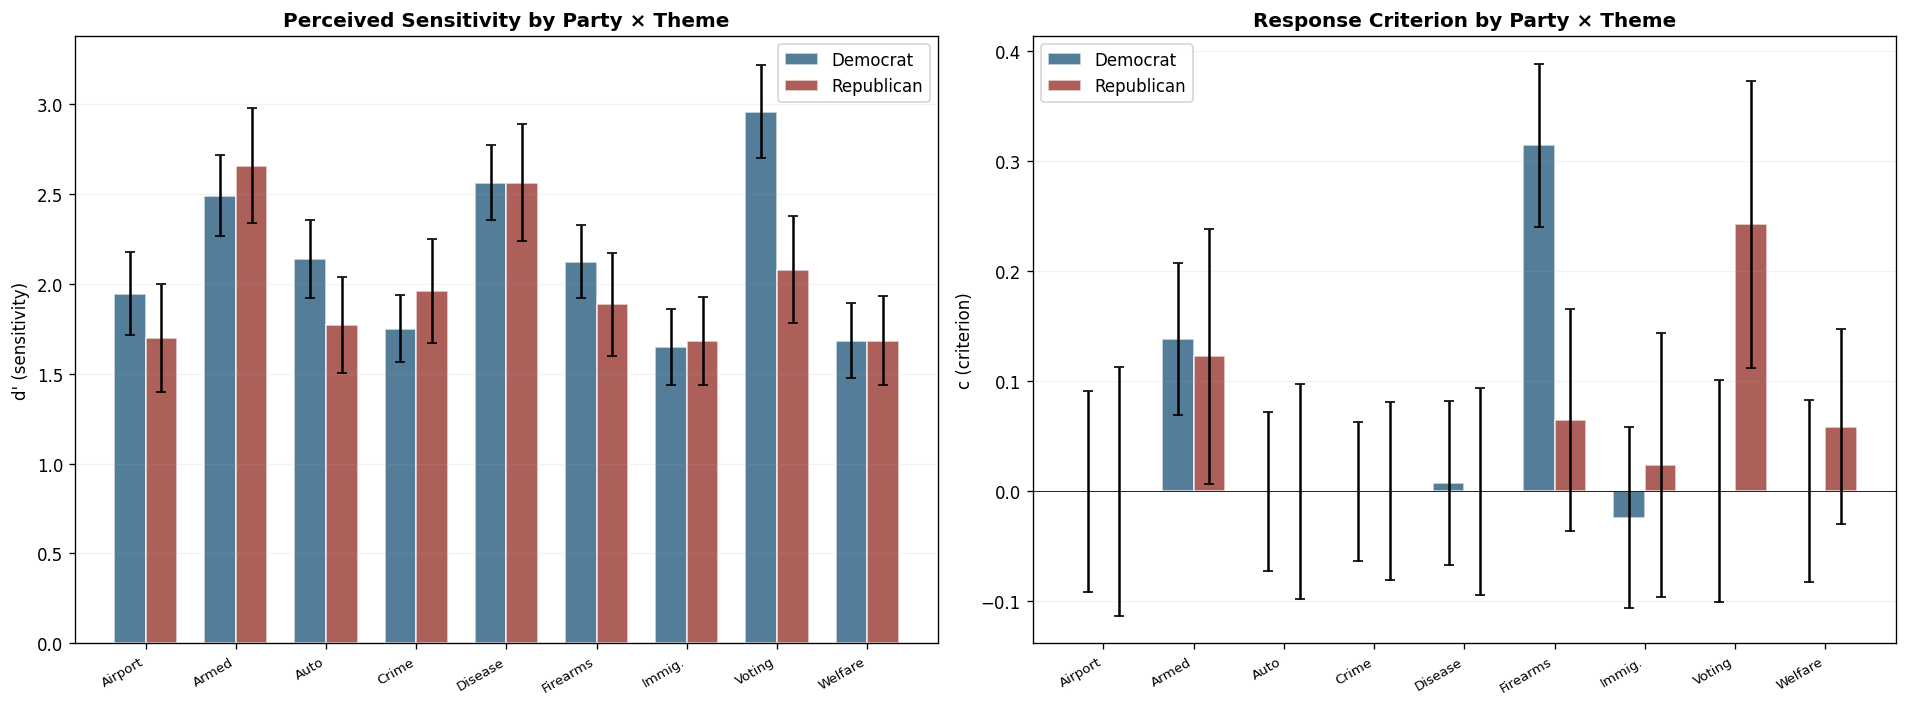

In [ ]:
# Participant-level aggregation for proper statistical tests
sdt_with_party = sdt_long.dropna(subset=['d_prime', 'c'])

# --- d' and c bar charts ---
theme_party = sdt_with_party.groupby(['theme', 'party_binary']).agg(
    d_prime_median=('d_prime', 'median'),
    d_prime_mean=('d_prime', 'mean'),
    d_prime_se=('d_prime', lambda x: x.std() / np.sqrt(len(x))),
    c_median=('c', 'median'),
    c_mean=('c', 'mean'),
    c_se=('c', lambda x: x.std() / np.sqrt(len(x))),
    n=('d_prime', 'count'),
).reset_index()

parties = ['Democrat', 'Republican']
themes_available = sorted(theme_party['theme'].unique())

fig, (ax_dp, ax_c) = plt.subplots(1, 2, figsize=(16, 6))

bar_width = 0.35
x = np.arange(len(themes_available))

for ax, metric, ylabel, title in [
    (ax_dp, 'd_prime', "d' (sensitivity)", "Perceived Sensitivity by Party × Theme"),
    (ax_c, 'c', 'c (criterion)', "Response Criterion by Party × Theme"),
]:
    for i, party in enumerate(parties):
        pdata = theme_party[theme_party['party_binary'] == party].set_index('theme')
        vals = [pdata.loc[t, f'{metric}_median'] if t in pdata.index else np.nan
                for t in themes_available]
        errs = [pdata.loc[t, f'{metric}_se'] * 1.96 if t in pdata.index else 0
                for t in themes_available]
        ax.bar(x + i * bar_width, vals, bar_width, yerr=errs,
               color=PARTY_COLORS[party], alpha=0.75, label=party,
               edgecolor='white', capsize=3)

    ax.set_xticks(x + bar_width / 2)
    ax.set_xticklabels([THEME_SHORT.get(t, t) for t in themes_available],
                       fontsize=8, rotation=30, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.axhline(0, color='black', linewidth=0.5)
    ax.grid(axis='y', alpha=0.15)

plt.tight_layout()
plt.show()

## Statistical Tests: Party Differences in d' and c
Participant-level aggregation before between-group tests.

In [ ]:
print("Party Differences in SDT Parameters (participant-level aggregation)")
print("=" * 80)
print(f"{'Theme':<20} {'Δd\' (R-D)':<12} {'p(d\')':<10} {'Δc (R-D)':<12} "
      f"{'p(c)':<10} {'n_D':<6} {'n_R':<6}")
print("-" * 80)

for theme in sorted(sdt_with_party['theme'].unique()):
    t_df = sdt_with_party[sdt_with_party['theme'] == theme]
    dem = t_df[t_df['party_binary'] == 'Democrat']
    rep = t_df[t_df['party_binary'] == 'Republican']

    if len(dem) < 3 or len(rep) < 3:
        continue

    # USE MEDIANS for reporting, t-test on raw values
    d_diff = rep['d_prime'].median() - dem['d_prime'].median()
    _, p_dp = mannwhitneyu(rep['d_prime'], dem['d_prime'], alternative='two-sided')

    c_diff = rep['c'].median() - dem['c'].median()
    _, p_c = mannwhitneyu(rep['c'], dem['c'], alternative='two-sided')

    sig_dp = '*' if p_dp < 0.05 else ''
    sig_c  = '*' if p_c  < 0.05 else ''
    name = THEME_NAMES.get(theme, theme)
    print(f"{name:<20} {d_diff:>+10.3f}{sig_dp:<2} {p_dp:<10.3f} "
          f"{c_diff:>+10.3f}{sig_c:<2} {p_c:<10.3f} {len(dem):<6} {len(rep):<6}")

print("\n* p < .05 (Mann-Whitney U, two-sided)")

Party Differences in SDT Parameters (participant-level aggregation)
Theme                Δd' (R-D)    p(d')      Δc (R-D)     p(c)       n_D    n_R   
--------------------------------------------------------------------------------
Airport Security         -0.246   0.578          +0.000   0.287      266    169   
Armed Conflict           +0.166   0.507          -0.016   0.578      258    163   
Autonomous Driving       -0.366   0.293          +0.000   0.818      252    169   
Criminal Justice         +0.208   0.209          +0.000   0.245      261    166   
Disease Testing          +0.000   0.695          -0.008*  0.034      235    158   
Firearms                 -0.238   0.979          -0.249*  0.000      257    174   
Immigration              +0.035   0.650          +0.048*  0.001      264    170   
Voting / Voter ID        -0.880*  0.001          +0.242*  0.000      244    169   
Welfare Eligibility      +0.000   0.612          +0.059*  0.007      267    181   

* p < .05 (Mann-Whit

## Pooled ROC: Grand-Average Across Themes

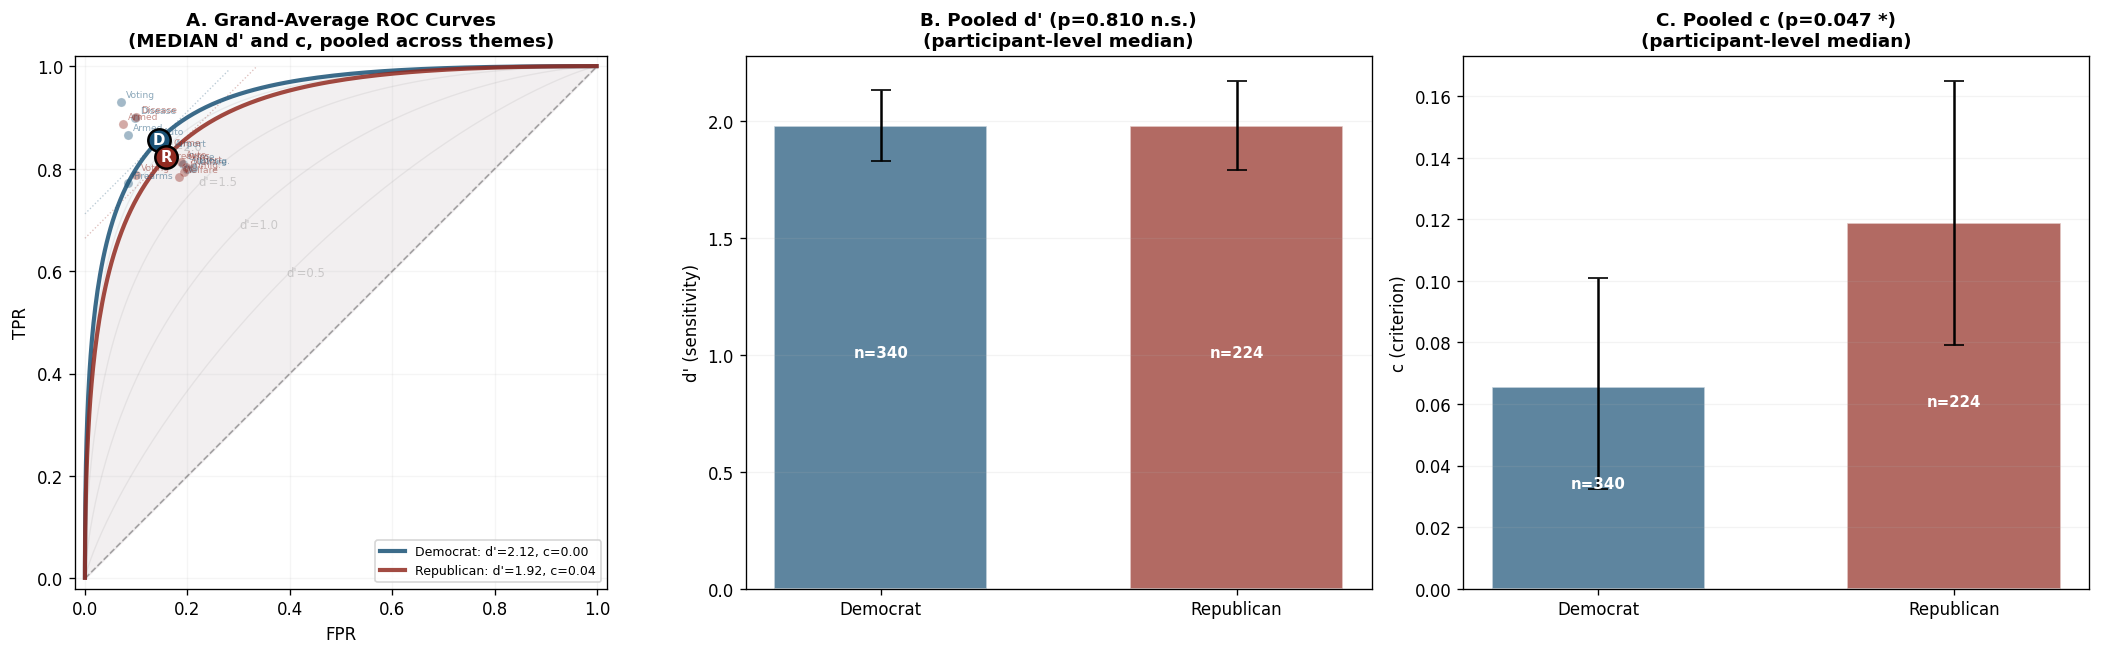


POOLED SDT COMPARISON (participant-level medians)
  Democrat:    d' median = 2.123, c median = 0.000
  Republican:  d' median = 1.894, c median = 0.039
  Δd' (R-D) = -0.229, p = 0.8103
  Δc  (R-D) = 0.039, p = 0.0469


In [ ]:
"""
Pooled ROC using MEDIANS for aggregation.
3-panel: Grand ROC | d' bars | c bars
"""

sdt_pooled = sdt_with_party.dropna(subset=['d_prime', 'c']).copy()

fig, (ax_main, ax_dprime, ax_c) = plt.subplots(1, 3, figsize=(18, 5.5))

# --- Panel A: Grand ROC ---
ax = ax_main
add_roc_background(ax)

for party in ['Democrat', 'Republican']:
    pdata = sdt_pooled[sdt_pooled['party_binary'] == party]
    if len(pdata) < 5:
        continue

    # MEDIAN d' and c (changed from mean)
    med_dp = pdata['d_prime'].median()
    med_c = pdata['c'].median()
    color = PARTY_COLORS[party]

    # ROC curve
    fc, tc = roc_curve_from_dprime(med_dp)
    ax.plot(fc, tc, color=color, linewidth=2.5, alpha=0.85,
            label=f"{party}: d'={med_dp:.2f}, c={med_c:.2f}")
    ax.fill_between(fc, fc, tc, color=color, alpha=0.04)

    # Operating point
    pt_f, pt_t = criterion_to_roc_point(med_dp, med_c)
    ax.scatter(pt_f, pt_t, c=color, s=180, marker='o',
               edgecolors='black', linewidth=1.5, zorder=5)
    short = 'D' if party == 'Democrat' else 'R'
    ax.annotate(short, (pt_f, pt_t), fontsize=9, fontweight='bold',
                color='white', ha='center', va='center', zorder=6)

    # Slope-1 tangent
    add_slope1_tangent(ax, med_dp, color=color, alpha=0.3)

    # Per-theme MEDIAN dots
    tm = pdata.groupby('theme').agg(dp=('d_prime', 'median'),
                                     cc=('c', 'median')).reset_index()
    for _, row in tm.iterrows():
        pf, pt = criterion_to_roc_point(row['dp'], row['cc'])
        ax.scatter(pf, pt, c=color, s=30, alpha=0.4,
                   edgecolors='white', linewidth=0.3)
        ax.annotate(THEME_SHORT.get(row['theme'], ''), (pf, pt),
                    fontsize=5.5, alpha=0.5, color=color,
                    xytext=(3, 3), textcoords='offset points')

ax.set_title('A. Grand-Average ROC Curves\n(MEDIAN d\' and c, pooled across themes)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=7.5, loc='lower right')

# --- Panel B: Pooled d' ---
ax = ax_dprime
rng = np.random.default_rng(42)
for i, party in enumerate(['Democrat', 'Republican']):
    # PARTICIPANT-LEVEL aggregation first
    part_dp = sdt_pooled[sdt_pooled['party_binary'] == party].groupby(
        'participant')['d_prime'].median().values
    if len(part_dp) < 3:
        continue
    boot = [rng.choice(part_dp, size=len(part_dp), replace=True).mean()
            for _ in range(2000)]
    ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
    mean_v = part_dp.mean()
    color = PARTY_COLORS[party]
    ax.bar(i, mean_v, color=color, alpha=0.7, width=0.6, edgecolor='white')
    ax.errorbar(i, mean_v, yerr=[[mean_v - ci_lo], [ci_hi - mean_v]],
                fmt='none', color='black', capsize=6, linewidth=1.5)
    ax.annotate(f'n={len(part_dp)}', (i, mean_v * 0.5), ha='center',
                fontsize=9, color='white', fontweight='bold')

# Participant-level test
part_dp_agg = sdt_pooled.groupby(['participant', 'party_binary'])['d_prime'].median().reset_index()
dem_dp = part_dp_agg.loc[part_dp_agg['party_binary'] == 'Democrat', 'd_prime']
rep_dp = part_dp_agg.loc[part_dp_agg['party_binary'] == 'Republican', 'd_prime']
if len(dem_dp) > 3 and len(rep_dp) > 3:
    u, p_dp = mannwhitneyu(dem_dp, rep_dp, alternative='two-sided')
    sig = '***' if p_dp < .001 else '**' if p_dp < .01 else '*' if p_dp < .05 else 'n.s.'
    ax.set_title(f"B. Pooled d' (p={p_dp:.3f} {sig})\n(participant-level median)",
                 fontsize=11, fontweight='bold')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Democrat', 'Republican'])
ax.set_ylabel("d' (sensitivity)")
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.15)

# --- Panel C: Pooled c ---
ax = ax_c
for i, party in enumerate(['Democrat', 'Republican']):
    part_c = sdt_pooled[sdt_pooled['party_binary'] == party].groupby(
        'participant')['c'].median().values
    if len(part_c) < 3:
        continue
    boot = [rng.choice(part_c, size=len(part_c), replace=True).mean()
            for _ in range(2000)]
    ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
    mean_v = part_c.mean()
    color = PARTY_COLORS[party]
    ax.bar(i, mean_v, color=color, alpha=0.7, width=0.6, edgecolor='white')
    ax.errorbar(i, mean_v, yerr=[[mean_v - ci_lo], [ci_hi - mean_v]],
                fmt='none', color='black', capsize=6, linewidth=1.5)
    ax.annotate(f'n={len(part_c)}', (i, mean_v * 0.5), ha='center',
                fontsize=9, color='white', fontweight='bold')

part_c_agg = sdt_pooled.groupby(['participant', 'party_binary'])['c'].median().reset_index()
dem_c = part_c_agg.loc[part_c_agg['party_binary'] == 'Democrat', 'c']
rep_c = part_c_agg.loc[part_c_agg['party_binary'] == 'Republican', 'c']
if len(dem_c) > 3 and len(rep_c) > 3:
    u, p_c = mannwhitneyu(dem_c, rep_c, alternative='two-sided')
    sig = '***' if p_c < .001 else '**' if p_c < .01 else '*' if p_c < .05 else 'n.s.'
    ax.set_title(f"C. Pooled c (p={p_c:.3f} {sig})\n(participant-level median)",
                 fontsize=11, fontweight='bold')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Democrat', 'Republican'])
ax.set_ylabel('c (criterion)')
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.15)

plt.tight_layout()
plt.show()

# --- Interpretation ---
print("\n" + "=" * 70)
print("POOLED SDT COMPARISON (participant-level medians)")
print("=" * 70)
print(f"  Democrat:    d' median = {dem_dp.median():.3f}, c median = {dem_c.median():.3f}")
print(f"  Republican:  d' median = {rep_dp.median():.3f}, c median = {rep_c.median():.3f}")
print(f"  Δd' (R-D) = {rep_dp.median() - dem_dp.median():.3f}, p = {p_dp:.4f}")
print(f"  Δc  (R-D) = {rep_c.median() - dem_c.median():.3f}, p = {p_c:.4f}")

## Per-Theme Summary Table (Median-Based)

In [ ]:
if len(roc_stats_df) > 0:
    print("\n" + "=" * 100)
    print("PER-THEME ROC SUMMARY (medians)")
    print("=" * 100)
    print(f"{'Theme':<20} {'Party':<12} {'n':>4} {'med d\'':>8} {'med c':>8} "
          f"{'med FPR':>8} {'med TPR':>8} {'med logR':>9}")
    print("—" * 85)
    for _, row in roc_stats_df.iterrows():
        print(f"  {THEME_NAMES.get(row['theme'], row['theme']):<18} "
              f"{row['party']:<12} {row['n']:>4} "
              f"{row['median_d_prime']:>8.3f} {row['median_c']:>8.3f} "
              f"{row['median_fpr']:>8.3f} {row['median_tpr']:>8.3f} "
              f"{row.get('median_log_ratio', np.nan):>9.3f}")


PER-THEME ROC SUMMARY (medians)
Theme                Party           n   med d'    med c  med FPR  med TPR  med logR
—————————————————————————————————————————————————————————————————————————————————————
  Disease Testing    Democrat      235    2.563    0.008    0.100    0.900     1.000
  Disease Testing    Republican    158    2.563   -0.000    0.099    0.900     1.000
  Armed Conflict     Democrat      258    2.492    0.139    0.067    0.854    -1.000
  Armed Conflict     Republican    163    2.658    0.123    0.055    0.855    -0.000
  Criminal Justice   Democrat      261    1.751   -0.000    0.190    0.816     0.000
  Criminal Justice   Republican    166    1.959   -0.000    0.105    0.814     0.000
  Welfare Eligibility Democrat      267    1.683   -0.000    0.195    0.832    -1.000
  Welfare Eligibility Republican    181    1.683    0.059    0.146    0.800     0.000
  Immigration        Democrat      264    1.648   -0.024    0.231    0.849     0.000
  Immigration        Republic

## Criterion Positioning: Base-Rate vs Threshold Relative to Slope=1 Tangent

For each party × theme, the slope=1 tangent point marks where FPR and FNR trade off 1:1 (criterion c=0).
We check whether each party's base-rate criterion (median c from FPR/TPR beliefs) and threshold
criterion (from error log_ratio) fall to the left or right of this neutral point.

Key question: Are immigration and voting the only domains where base-rate and threshold criteria
fall on *opposite sides* of the tangent for D vs R? (Seth's "divergent information environments" hypothesis)


In [ ]:
# Criterion positioning relative to slope=1 tangent (c=0)
# c > 0 → conservative (right of tangent in z-space, LEFT in ROC space → lower FPR)
# c < 0 → liberal (left of tangent in z-space, RIGHT in ROC space → higher FPR)

positioning_rows = []

for theme in THEMES:
    td = sdt_long[sdt_long['theme'] == theme].dropna(subset=['d_prime', 'c'])

    for party in ['Democrat', 'Republican']:
        pdata = td[td['party_binary'] == party]
        if len(pdata) < 3:
            continue

        med_dp = pdata['d_prime'].median()
        med_c = pdata['c'].median()

        # Threshold criterion from log_ratio
        lr_data = pdata.dropna(subset=['log_ratio'])
        if len(lr_data) >= 3:
            med_lr = lr_data['log_ratio'].median()
            c_from_lr = -med_lr / 2.0
        else:
            c_from_lr = np.nan

        # Slope=1 tangent is at c=0
        # Position: c > 0 means conservative of tangent, c < 0 means liberal
        baserate_side = 'conservative' if med_c > 0 else 'liberal'
        threshold_side = 'conservative' if c_from_lr > 0 else 'liberal' if not np.isnan(c_from_lr) else 'n/a'
        same_side = baserate_side == threshold_side if threshold_side != 'n/a' else None

        positioning_rows.append({
            'theme': theme,
            'theme_name': THEME_NAMES[theme],
            'party': party,
            'median_c_baserate': med_c,
            'c_threshold': c_from_lr,
            'baserate_side': baserate_side,
            'threshold_side': threshold_side,
            'same_side': same_side,
            'median_d_prime': med_dp,
        })

pos_df = pd.DataFrame(positioning_rows)

# Display table
print("=" * 110)
print("CRITERION POSITIONING RELATIVE TO SLOPE=1 TANGENT (c=0)")
print("=" * 110)
print(f"{'Theme':<20} {'Party':<12} {'c_base':>8} {'side_B':>12} "
      f"{'c_thresh':>8} {'side_T':>12} {'same?':>6}")
print("-" * 110)

for theme in THEMES:
    for party in ['Democrat', 'Republican']:
        row = pos_df[(pos_df['theme'] == theme) & (pos_df['party'] == party)]
        if len(row) == 0:
            continue
        r = row.iloc[0]
        same_str = 'YES' if r['same_side'] == True else 'NO' if r['same_side'] == False else '—'
        print(f"  {THEME_NAMES[theme]:<18} {party:<12} {r['median_c_baserate']:>+8.3f} "
              f"{r['baserate_side']:>12} {r['c_threshold']:>+8.3f} "
              f"{r['threshold_side']:>12} {same_str:>6}")
    print()

# Highlight divergent-information-environment domains
print("\n" + "=" * 80)
print("DIVERGENT INFORMATION ENVIRONMENTS CHECK")
print("=" * 80)
print("Domains where D and R have base-rate criteria on OPPOSITE sides of tangent")
print("AND/OR threshold criteria on opposite sides:\n")

for theme in THEMES:
    d_row = pos_df[(pos_df['theme'] == theme) & (pos_df['party'] == 'Democrat')]
    r_row = pos_df[(pos_df['theme'] == theme) & (pos_df['party'] == 'Republican')]
    if len(d_row) == 0 or len(r_row) == 0:
        continue
    d, r = d_row.iloc[0], r_row.iloc[0]

    base_diverge = d['baserate_side'] != r['baserate_side']
    thresh_diverge = (d['threshold_side'] != r['threshold_side']
                      and d['threshold_side'] != 'n/a'
                      and r['threshold_side'] != 'n/a')

    # Check if base-rate vs threshold flip differently by party
    d_flip = d['baserate_side'] != d['threshold_side'] if d['threshold_side'] != 'n/a' else None
    r_flip = r['baserate_side'] != r['threshold_side'] if r['threshold_side'] != 'n/a' else None
    cross_flip = (d_flip is not None and r_flip is not None
                  and d_flip != r_flip)

    flags = []
    if base_diverge: flags.append('base-rate sides differ')
    if thresh_diverge: flags.append('threshold sides differ')
    if cross_flip: flags.append('B-T flip direction differs by party')

    if flags:
        print(f"  *** {THEME_NAMES[theme]}: {'; '.join(flags)}")
    else:
        print(f"      {THEME_NAMES[theme]}: consistent pattern across parties")


CRITERION POSITIONING RELATIVE TO SLOPE=1 TANGENT (c=0)
Theme                Party          c_base       side_B c_thresh       side_T  same?
--------------------------------------------------------------------------------------------------------------
  Disease Testing    Democrat       +0.008 conservative   -0.500      liberal     NO
  Disease Testing    Republican     -0.000      liberal   -0.500      liberal    YES

  Armed Conflict     Democrat       +0.139 conservative   +0.500 conservative    YES
  Armed Conflict     Republican     +0.123 conservative   +0.000      liberal     NO

  Criminal Justice   Democrat       -0.000      liberal   -0.000      liberal    YES
  Criminal Justice   Republican     -0.000      liberal   -0.000      liberal    YES

  Welfare Eligibility Democrat       -0.000      liberal   +0.500 conservative     NO
  Welfare Eligibility Republican     +0.059 conservative   -0.000      liberal     NO

  Immigration        Democrat       -0.024      liberal   -0.0

## Criterion Extremity: Which Party Holds the Most Extreme Criteria?

Seth's observation: Democrats hold both the farthest-right and farthest-left criterion
points in 6/9 domains (with voting as the exception for both).
This suggests D's have higher criterion *variance* across domains.


In [ ]:
# For each theme, find which party's median criterion is most extreme in each direction
extremity_rows = []

for theme in THEMES:
    td = sdt_long[sdt_long['theme'] == theme].dropna(subset=['c'])
    theme_data = {}
    for party in ['Democrat', 'Republican']:
        pdata = td[td['party_binary'] == party]
        if len(pdata) >= 3:
            theme_data[party] = {
                'median_c': pdata['c'].median(),
                'mean_c': pdata['c'].mean(),
                'std_c': pdata['c'].std(),
                'iqr_c': pdata['c'].quantile(0.75) - pdata['c'].quantile(0.25),
                'n': len(pdata),
            }
    if 'Democrat' in theme_data and 'Republican' in theme_data:
        d_c = theme_data['Democrat']['median_c']
        r_c = theme_data['Republican']['median_c']
        # Which party has the more liberal criterion (lower c = more right in ROC)?
        most_liberal = 'Democrat' if d_c < r_c else 'Republican'
        # Which party has the more conservative criterion (higher c = more left in ROC)?
        most_conservative = 'Democrat' if d_c > r_c else 'Republican'

        extremity_rows.append({
            'theme': theme, 'theme_name': THEME_NAMES[theme],
            'D_median_c': d_c, 'R_median_c': r_c,
            'D_std': theme_data['Democrat']['std_c'],
            'R_std': theme_data['Republican']['std_c'],
            'D_iqr': theme_data['Democrat']['iqr_c'],
            'R_iqr': theme_data['Republican']['iqr_c'],
            'more_liberal_c': most_liberal,
            'more_conservative_c': most_conservative,
        })

ext_df = pd.DataFrame(extremity_rows)

print("=" * 100)
print("CRITERION EXTREMITY BY PARTY × THEME")
print("=" * 100)
print(f"{'Theme':<20} {'D med c':>8} {'R med c':>8} {'D IQR':>8} {'R IQR':>8} "
      f"{'Most liberal':>14} {'Most conserv':>14}")
print("-" * 100)
for _, row in ext_df.iterrows():
    print(f"  {row['theme_name']:<18} {row['D_median_c']:>+8.3f} {row['R_median_c']:>+8.3f} "
          f"{row['D_iqr']:>8.3f} {row['R_iqr']:>8.3f} "
          f"{row['more_liberal_c']:>14} {row['more_conservative_c']:>14}")

# Summary counts
d_most_liberal = (ext_df['more_liberal_c'] == 'Democrat').sum()
d_most_conservative = (ext_df['more_conservative_c'] == 'Democrat').sum()
print(f"\nDemocrats hold the most LIBERAL criterion in {d_most_liberal}/9 themes")
print(f"Democrats hold the most CONSERVATIVE criterion in {d_most_conservative}/9 themes")
print(f"(Seth's observation: D's hold farthest-right AND farthest-left in 6/9 themes)")

# Variance comparison
print(f"\n{'Theme':<20} {'D std(c)':>10} {'R std(c)':>10} {'Higher var':>12}")
print("-" * 55)
d_higher_var = 0
for _, row in ext_df.iterrows():
    higher = 'Democrat' if row['D_std'] > row['R_std'] else 'Republican'
    if higher == 'Democrat': d_higher_var += 1
    print(f"  {row['theme_name']:<18} {row['D_std']:>10.3f} {row['R_std']:>10.3f} {higher:>12}")
print(f"\nDemocrats have higher criterion variance in {d_higher_var}/9 themes")


CRITERION EXTREMITY BY PARTY × THEME
Theme                 D med c  R med c    D IQR    R IQR   Most liberal   Most conserv
----------------------------------------------------------------------------------------------------
  Disease Testing      +0.008   -0.000    0.240    0.264     Republican       Democrat
  Armed Conflict       +0.139   +0.123    0.511    0.467     Republican       Democrat
  Criminal Justice     -0.000   -0.000    0.469    0.408     Republican     Republican
  Welfare Eligibility   -0.000   +0.059    0.560    0.553       Democrat     Republican
  Immigration          -0.024   +0.024    0.537    0.582       Democrat     Republican
  Voting / Voter ID    -0.000   +0.242    0.577    0.770       Democrat     Republican
  Airport Security     -0.000   +0.000    0.692    0.648       Democrat     Republican
  Firearms             +0.314   +0.065    0.774    0.592     Republican       Democrat
  Autonomous Driving   +0.000   +0.000    0.475    0.417     Republican     Re

## Below-Diagonal Validation of Exclusion Criteria

Operating points below the x=y diagonal (FPR > TPR) indicate the participant
believes the system performs *worse than chance*. This section:
1. Computes per-participant below-diagonal rates across themes
2. Tests whether being below-diagonal on one theme predicts being below on others
3. Validates existing exclusion criteria by checking if excluded participants
   are disproportionately below-diagonal


In [ ]:
# --- Below-diagonal analysis ---
# Use ALL participants (not just attentive) to compare included vs excluded

df_all = df.copy()
df_all['party_binary'] = np.where(
    df_all['party_id_7'] <= 3, 'Democrat',
    np.where(df_all['party_id_7'] >= 5, 'Republican', 'Independent')
)

# Compute per-theme below-diagonal flag for each participant
for theme in THEMES:
    fpr_col, tpr_col = f'{theme}_fpr', f'{theme}_tpr'
    if fpr_col in df_all.columns and tpr_col in df_all.columns:
        df_all[f'{theme}_below_diag'] = (
            (df_all[fpr_col] > df_all[tpr_col]) &
            df_all[fpr_col].notna() &
            df_all[tpr_col].notna()
        ).astype(int)
    else:
        df_all[f'{theme}_below_diag'] = np.nan

below_diag_cols = [f'{t}_below_diag' for t in THEMES if f'{t}_below_diag' in df_all.columns]
df_all['n_below_diagonal'] = df_all[below_diag_cols].sum(axis=1)
df_all['n_themes_with_sdt'] = df_all[[f'{t}_fpr' for t in THEMES if f'{t}_fpr' in df_all.columns]].notna().sum(axis=1)
df_all['pct_below_diagonal'] = df_all['n_below_diagonal'] / df_all['n_themes_with_sdt']

# 1. Distribution of below-diagonal counts
print("=" * 80)
print("BELOW-DIAGONAL OPERATING POINTS")
print("=" * 80)
print("\nDistribution of below-diagonal theme counts (all participants):")
print(df_all['n_below_diagonal'].value_counts().sort_index().to_string())

# 2. Cross-theme prediction: does being below on one predict being below on others?
print("\n\n--- Cross-theme correlation of below-diagonal status ---")
below_matrix = df_all[below_diag_cols].copy()
below_matrix.columns = [THEME_SHORT.get(c.replace('_below_diag', ''), c) for c in below_matrix.columns]
corr = below_matrix.corr()
mean_off_diag = corr.values[np.triu_indices_from(corr.values, k=1)].mean()
print(f"Mean off-diagonal correlation: {mean_off_diag:.3f}")
if mean_off_diag > 0.1:
    print("→ Positive cross-theme correlation: below-diagonal is a participant trait, not random noise")
elif mean_off_diag > 0.0:
    print("→ Weak positive correlation: some trait-like quality but mostly theme-specific")
else:
    print("→ No cross-theme pattern: below-diagonal appears theme-specific")

# 3. Validate exclusions: are excluded participants more likely below-diagonal?
if 'passes_attention' in df_all.columns:
    included = df_all[df_all['passes_attention'] == 1]
    excluded = df_all[df_all['passes_attention'] == 0]

    inc_pct = included['pct_below_diagonal'].mean()
    exc_pct = excluded['pct_below_diagonal'].mean()

    print(f"\n\n--- Exclusion validation ---")
    print(f"  Included (passes_attention=1): n={len(included)}, "
          f"mean {inc_pct:.1%} of themes below diagonal")
    print(f"  Excluded (passes_attention=0): n={len(excluded)}, "
          f"mean {exc_pct:.1%} of themes below diagonal")

    if len(excluded) > 3 and len(included) > 3:
        u, p_val = mannwhitneyu(
            excluded['pct_below_diagonal'].dropna(),
            included['pct_below_diagonal'].dropna(),
            alternative='greater'
        )
        print(f"  Mann-Whitney U (excluded > included): p = {p_val:.4f}")

        # What % of excluded participants have ANY below-diagonal?
        exc_any_below = (excluded['n_below_diagonal'] > 0).mean()
        inc_any_below = (included['n_below_diagonal'] > 0).mean()
        print(f"\n  % with ≥1 below-diagonal theme:")
        print(f"    Included: {inc_any_below:.1%}")
        print(f"    Excluded: {exc_any_below:.1%}")

        # What % of excluded have MAJORITY below-diagonal?
        exc_majority = (excluded['pct_below_diagonal'] > 0.5).mean()
        inc_majority = (included['pct_below_diagonal'] > 0.5).mean()
        print(f"\n  % with >50% themes below diagonal:")
        print(f"    Included: {inc_majority:.1%}")
        print(f"    Excluded: {exc_majority:.1%}")
        if exc_majority > 0.5:
            print(f"    → ≥50% of excluded participants are majority below-diagonal ✓")
        else:
            print(f"    → <50% of excluded are majority below-diagonal")
else:
    print("passes_attention column not found — cannot validate exclusions")

# 4. Per-theme below-diagonal rates by party (attentive only)
print("\n\n--- Below-diagonal rates by party × theme (attentive only) ---")
print(f"{'Theme':<20} {'D rate':>8} {'R rate':>8} {'D n':>5} {'R n':>5}")
print("-" * 50)
att = df_all[df_all['passes_attention'] == 1] if 'passes_attention' in df_all.columns else df_all
for theme in THEMES:
    col = f'{theme}_below_diag'
    if col not in att.columns:
        continue
    for_d = att[att['party_binary'] == 'Democrat'][col].dropna()
    for_r = att[att['party_binary'] == 'Republican'][col].dropna()
    if len(for_d) > 0 and len(for_r) > 0:
        print(f"  {THEME_NAMES[theme]:<18} {for_d.mean():>8.1%} {for_r.mean():>8.1%} "
              f"{len(for_d):>5} {len(for_r):>5}")


BELOW-DIAGONAL OPERATING POINTS

Distribution of below-diagonal theme counts (all participants):
n_below_diagonal
0    337
1    141
2     83
3     54
4     30
5     16
6      9


--- Cross-theme correlation of below-diagonal status ---
Mean off-diagonal correlation: 0.149
→ Positive cross-theme correlation: below-diagonal is a participant trait, not random noise


--- Exclusion validation ---
  Included (passes_attention=1): n=649, mean 14.8% of themes below diagonal
  Excluded (passes_attention=0): n=21, mean 36.7% of themes below diagonal
  Mann-Whitney U (excluded > included): p = 0.0001

  % with ≥1 below-diagonal theme:
    Included: 48.8%
    Excluded: 76.2%

  % with >50% themes below diagonal:
    Included: 7.2%
    Excluded: 38.1%
    → <50% of excluded are majority below-diagonal


--- Below-diagonal rates by party × theme (attentive only) ---
Theme                  D rate   R rate   D n   R n
--------------------------------------------------
  Disease Testing        8.2%   

## Logical Self-Consistency of Base-Rate Beliefs

When a participant answers both questions from the same population (FP+TN or FN+TP),
their answers should sum to 1000 (since they're estimating complementary counts from the
same 1000-person population). Deviations indicate logical inconsistency in base-rate reasoning.

Seth's observation: On welfare, polarization appears driven by Democrats being "less
logically self-consistent on base rates." This section quantifies that.


In [ ]:
# Consistency analysis requires raw base-rate columns (base_{theme}_{fp/tn/fn/tp})
# These are in the wide-format df from the cleaning pipeline

consist_rows = []
QUESTION_TYPES = ['fp', 'tn', 'fn', 'tp']

for theme in THEMES:
    for pair_label, (q_a, q_b) in [('FP+TN', ('fp', 'tn')), ('FN+TP', ('fn', 'tp'))]:
        col_a = f'base_{theme}_{q_a}'
        col_b = f'base_{theme}_{q_b}'

        if col_a not in df.columns or col_b not in df.columns:
            continue

        both = df[['passes_attention', 'party_binary', col_a, col_b]].copy()
        both[col_a] = pd.to_numeric(both[col_a], errors='coerce')
        both[col_b] = pd.to_numeric(both[col_b], errors='coerce')
        both = both.dropna(subset=[col_a, col_b])

        # Filter to attentive
        if 'passes_attention' in both.columns:
            both = both[both['passes_attention'] == 1]

        if len(both) == 0:
            continue

        both['pair_sum'] = both[col_a] + both[col_b]
        both['deviation'] = both['pair_sum'] - 1000
        both['abs_deviation'] = both['deviation'].abs()

        for party_label in ['Democrat', 'Republican', 'Overall']:
            if party_label == 'Overall':
                sub = both
            else:
                sub = both[both['party_binary'] == party_label]

            if len(sub) < 2:
                continue

            consist_rows.append({
                'theme': theme, 'theme_name': THEME_NAMES[theme],
                'pair': pair_label, 'party': party_label,
                'n': len(sub),
                'mean_sum': sub['pair_sum'].mean(),
                'mean_deviation': sub['deviation'].mean(),
                'mean_abs_deviation': sub['abs_deviation'].mean(),
                'median_abs_deviation': sub['abs_deviation'].median(),
                'pct_perfect': (sub['pair_sum'] == 1000).mean() * 100,
                'pct_close': ((sub['pair_sum'] >= 900) & (sub['pair_sum'] <= 1100)).mean() * 100,
                'std_deviation': sub['deviation'].std(),
            })

consist_df = pd.DataFrame(consist_rows)

if len(consist_df) > 0:
    print("=" * 100)
    print("BASE-RATE LOGICAL SELF-CONSISTENCY (complementary pairs should sum to 1000)")
    print("=" * 100)
    print("\nAttentive participants only\n")
    print(f"{'Theme':<20} {'Pair':<8} {'Party':<12} {'n':>4} {'Mean Sum':>10} "
          f"{'Mean Dev':>10} {'Med |Dev|':>10} {'% Perfect':>10} {'% ±100':>8}")
    print("-" * 100)
    for _, row in consist_df.sort_values(['theme', 'pair', 'party']).iterrows():
        print(f"  {THEME_NAMES.get(row['theme'], row['theme']):<18} {row['pair']:<8} "
              f"{row['party']:<12} {row['n']:>4.0f} {row['mean_sum']:>10.1f} "
              f"{row['mean_deviation']:>+10.1f} {row['median_abs_deviation']:>10.1f} "
              f"{row['pct_perfect']:>9.1f}% {row['pct_close']:>7.1f}%")

    # Party comparison: is one party systematically less consistent?
    print("\n\n--- Party Consistency Comparison (mean |deviation| from 1000) ---")
    party_consist = consist_df[consist_df['party'] != 'Overall'].copy()
    if len(party_consist) > 0:
        party_summary = party_consist.groupby('party').agg(
            grand_mean_abs_dev=('mean_abs_deviation', 'mean'),
            grand_median_abs_dev=('median_abs_deviation', 'mean'),
            n_pairs=('n', 'sum'),
        )
        print(party_summary.to_string())

        # Per-theme comparison
        print(f"\n{'Theme':<20} {'D |dev|':>10} {'R |dev|':>10} {'Less consistent':>18}")
        print("-" * 60)
        d_worse_count = 0
        for theme in THEMES:
            d_data = consist_df[(consist_df['theme'] == theme) & (consist_df['party'] == 'Democrat')]
            r_data = consist_df[(consist_df['theme'] == theme) & (consist_df['party'] == 'Republican')]
            if len(d_data) > 0 and len(r_data) > 0:
                d_mad = d_data['mean_abs_deviation'].mean()
                r_mad = r_data['mean_abs_deviation'].mean()
                worse = 'Democrat' if d_mad > r_mad else 'Republican'
                if worse == 'Democrat':
                    d_worse_count += 1
                print(f"  {THEME_NAMES[theme]:<18} {d_mad:>10.1f} {r_mad:>10.1f} {worse:>18}")
        n_themes_compared = len([t for t in THEMES
            if len(consist_df[(consist_df['theme']==t) & (consist_df['party']=='Democrat')]) > 0
            and len(consist_df[(consist_df['theme']==t) & (consist_df['party']=='Republican')]) > 0])
        print(f"\nDemocrats less consistent in {d_worse_count}/{n_themes_compared} themes")
else:
    print("No consistency pairs found. Check that base_{theme}_{fp/tn/fn/tp} columns exist.")
    print("Available columns matching 'base_':", [c for c in df.columns if c.startswith('base_')][:20])


BASE-RATE LOGICAL SELF-CONSISTENCY (complementary pairs should sum to 1000)

Attentive participants only

Theme                Pair     Party           n   Mean Sum   Mean Dev  Med |Dev|  % Perfect   % ±100
----------------------------------------------------------------------------------------------------
  Airport Security   FN+TP    Democrat      136      827.7     -172.3       43.0      33.8%    58.1%
  Airport Security   FN+TP    Overall       260      835.9     -164.1       43.0      28.8%    60.0%
  Airport Security   FN+TP    Republican     98      854.7     -145.3       46.5      18.4%    62.2%
  Airport Security   FP+TN    Democrat      123      932.8      -67.2       51.0      24.4%    57.7%
  Airport Security   FP+TN    Overall       228      965.3      -34.7       39.0      28.1%    60.5%
  Airport Security   FP+TN    Republican     71     1025.0      +25.0       34.0      31.0%    64.8%
  Armed Conflict     FN+TP    Democrat      126      950.6      -49.4       57.5      